In [7]:
# Import required libraries
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import xgboost as xgb

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [8]:
# Load the dataset
df = pd.read_csv('asteroids_cleaned.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'asteroids_cleaned.csv'

In [ ]:
# Save the current DataFrame back to a CSV file
df.to_csv("asteroids_cleaned.csv", index=False)

In [ ]:
# Display the first 5 rows to inspect the structure and data
df.head()

,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,is_potentially_hazardous_asteroid,is_sentry_object,epoch_date_close_approach,relative_velocity_km_per_sec,miss_distance_kilometers
0,20.16,0.246919,0.552128,True,False,1736208480000,16.548994,1.849152e+07
1,18.54,0.520661,1.164233,False,False,1736238240000,15.276752,1.213633e+07
2,21.58,0.128397,0.287104,False,False,1736238060000,21.648876,5.823974e+07
3,22.29,0.092588,0.207033,False,False,1736236080000,8.989291,9.414482e+06
4,20.91,0.174805,0.390877,True,False,1736290080000,19.133631,7.346700e+07


In [ ]:
# Get a quick summary of the dataframe with data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6101 entries, 0 to 6100
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   absolute_magnitude_h               6101 non-null   float64
 1   estimated_diameter_min_km          6101 non-null   float64
 2   estimated_diameter_max_km          6101 non-null   float64
 3   is_potentially_hazardous_asteroid  6101 non-null   bool   
 4   is_sentry_object                   6101 non-null   bool   
 5   epoch_date_close_approach          6101 non-null   int64  
 6   relative_velocity_km_per_sec       6101 non-null   float64
 7   miss_distance_kilometers           6101 non-null   float64
dtypes: bool(2), float64(5), int64(1)
memory usage: 298.0 KB


In [ ]:
# Drop irrelevant or redundant columns from the dataset to simplify the model
df.drop(columns=["nasa_jpl_url", "designation", "id", "neo_reference_id", "name", "orbiting_body", "close_approach_date_full", "close_approach_date"], inplace=True, errors='ignore')

In [ ]:
# Check null percentages for all variables
null_percentages = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_percentages)

absolute_magnitude_h                 0.0
estimated_diameter_min_km            0.0
estimated_diameter_max_km            0.0
is_potentially_hazardous_asteroid    0.0
is_sentry_object                     0.0
epoch_date_close_approach            0.0
relative_velocity_km_per_sec         0.0
miss_distance_kilometers             0.0
dtype: float64


In [ ]:
# Remove highly correlated or duplicate measurement units
df.drop(columns=["estimated_diameter_min_m", "estimated_diameter_max_m", "estimated_diameter_min_miles", "estimated_diameter_max_miles", "estimated_diameter_min_feet", "estimated_diameter_max_feet", "relative_velocity_km_per_hour", "relative_velocity_miles_per_hour", "miss_distance_astronomical", "miss_distance_lunar", "miss_distance_miles"], inplace=True, errors='ignore')

In [ ]:
# Drop any columns that contain at least one missing value
df.dropna(axis=1, inplace=True)

In [ ]:
# Re-check the DataFrame info to confirm column drops and data consistency
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6101 entries, 0 to 6100
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   absolute_magnitude_h               6101 non-null   float64
 1   estimated_diameter_min_km          6101 non-null   float64
 2   estimated_diameter_max_km          6101 non-null   float64
 3   is_potentially_hazardous_asteroid  6101 non-null   bool   
 4   is_sentry_object                   6101 non-null   bool   
 5   epoch_date_close_approach          6101 non-null   int64  
 6   relative_velocity_km_per_sec       6101 non-null   float64
 7   miss_distance_kilometers           6101 non-null   float64
dtypes: bool(2), float64(5), int64(1)
memory usage: 298.0 KB


In [ ]:
# Verify the top rows again after the cleaning process
df.head()

,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,is_potentially_hazardous_asteroid,is_sentry_object,epoch_date_close_approach,relative_velocity_km_per_sec,miss_distance_kilometers
0,20.16,0.246919,0.552128,True,False,1736208480000,16.548994,1.849152e+07
1,18.54,0.520661,1.164233,False,False,1736238240000,15.276752,1.213633e+07
2,21.58,0.128397,0.287104,False,False,1736238060000,21.648876,5.823974e+07
3,22.29,0.092588,0.207033,False,False,1736236080000,8.989291,9.414482e+06
4,20.91,0.174805,0.390877,True,False,1736290080000,19.133631,7.346700e+07


In [ ]:
# Get the final count of rows and columns of the cleaned DataFrame
df.shape

(6101, 8)

In [ ]:
# Export the final cleaned dataset to a CSV file
df.to_csv('asteroids_cleaned.csv', index=False)

visuals

In [ ]:
# Configure global Matplotlib parameters for consistent styling of plots
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Times New Roman'],
    'font.size': 12,              
    'axes.titlesize': 20,       
    'axes.labelsize': 14,  
    'axes.labelcolor': 'darkgrey',      
})

In [ ]:
# Generate descriptive statistics for the 'miss_distance_kilometers' variable
df['miss_distance_kilometers'].describe()

count    6.101000e+03
mean     2.517659e+07
std      2.254705e+07
min      6.599181e+03
25%      5.632062e+06
50%      1.827075e+07
75%      4.199399e+07
max      7.478989e+07
Name: miss_distance_kilometers, dtype: float64

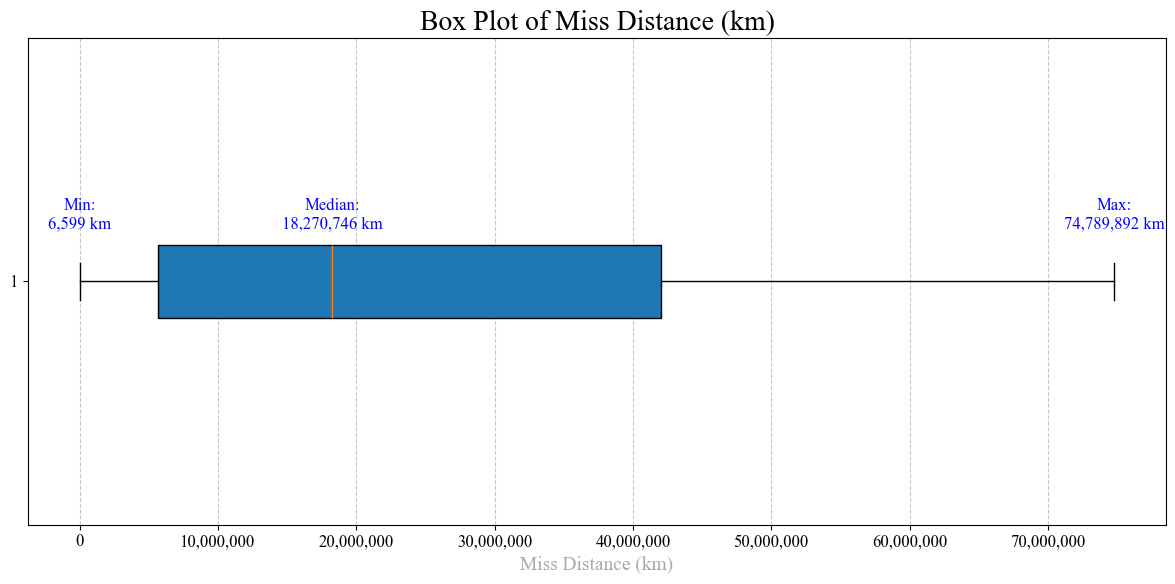

In [ ]:
# Create a horizontal box plot for 'miss_distance_kilometers' with custom formatting and statistical annotations
from matplotlib import ticker

plt.figure(figsize=(12, 6))
miss_bp = plt.boxplot(df['miss_distance_kilometers'], vert=False, patch_artist=True, whis=[0, 100])
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Box Plot of Miss Distance (kilometers)')
plt.xlabel('Miss distance (km)', rotation=0)

stats = df['miss_distance_kilometers'].describe()
vals_to_annotate = {
    'Min': stats['min'],
    'Median': stats['50%'],
    'Max': stats['max'],
}

for label, val in vals_to_annotate.items():
    plt.text(val, 1.1, f'{label}:\n{val:,.0f} km', 
             ha='center', va='bottom', color='blue')

plt.title('Box Plot of Miss Distance (km)')
plt.xlabel('Miss Distance (km)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

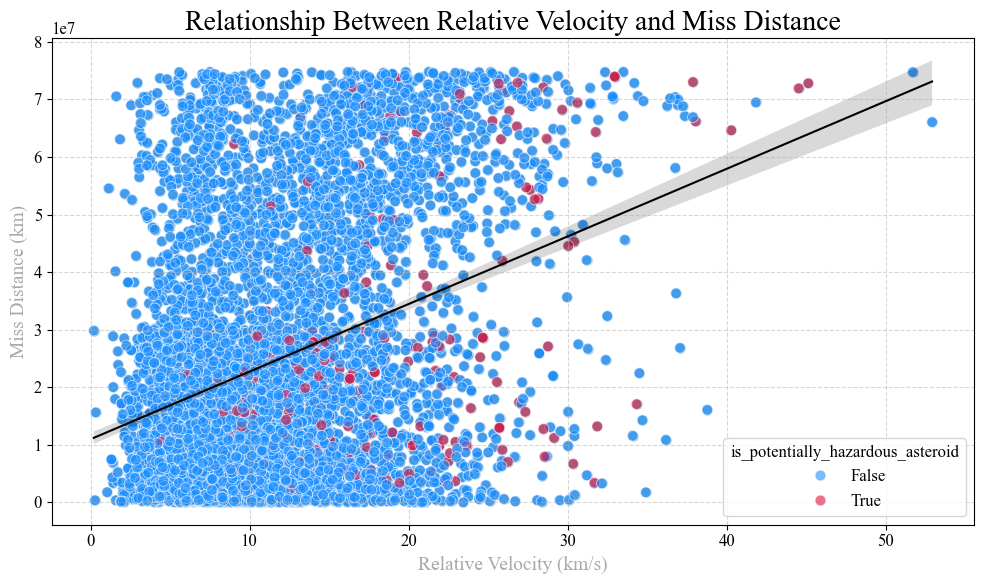

In [ ]:
# Create a scatter plot with a regression line to analyze the correlation between velocity and miss distance, highlighting hazardous asteroids
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='relative_velocity_km_per_sec',
    y='miss_distance_kilometers',
    alpha=0.6,
    edgecolor='w',
    s=60
)

sns.scatterplot(
    data=df,
    x='relative_velocity_km_per_sec',
    y='miss_distance_kilometers',
    hue='is_potentially_hazardous_asteroid',
    palette={False: 'dodgerblue', True: 'crimson'},
    alpha=0.6,
    edgecolor='w',
    s=60,
    legend='brief'
)

sns.regplot(
    data=df,
    x='relative_velocity_km_per_sec',
    y='miss_distance_kilometers',
    scatter=False,
    color='black',
    line_kws={'linewidth': 1.5}
)

plt.title('Relationship Between Relative Velocity and Miss Distance')
plt.xlabel('Relative Velocity (km/s)')
plt.ylabel('Miss Distance (km)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

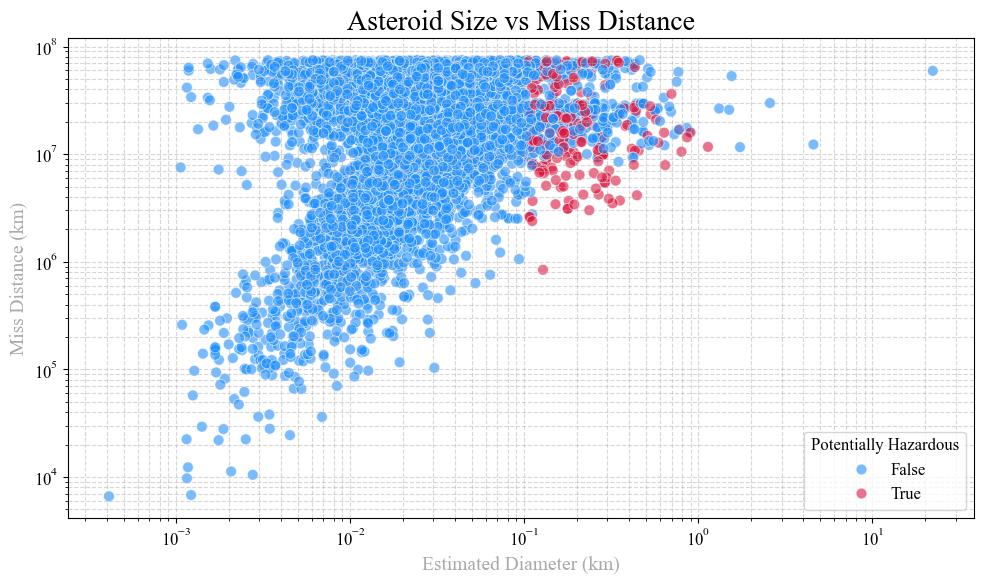

In [ ]:
# Create a log-scaled scatter plot to compare asteroid diameter against miss distance, categorized by hazard status to identify if larger asteroids tend to have closer approaches
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x= df['estimated_diameter_min_km'],
    y=df['miss_distance_kilometers'],
    hue=df['is_potentially_hazardous_asteroid'],
    palette={False: 'dodgerblue', True: 'crimson'},
    alpha=0.6,
    edgecolor='w',
    s=60
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Estimated Diameter (km)')
plt.ylabel('Miss Distance (km)')
plt.title('Asteroid Size vs Miss Distance')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(title='Potentially Hazardous', loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# Concise summary of the final cleaned DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6101 entries, 0 to 6100
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   absolute_magnitude_h               6101 non-null   float64
 1   estimated_diameter_min_km          6101 non-null   float64
 2   estimated_diameter_max_km          6101 non-null   float64
 3   is_potentially_hazardous_asteroid  6101 non-null   bool   
 4   is_sentry_object                   6101 non-null   bool   
 5   epoch_date_close_approach          6101 non-null   int64  
 6   relative_velocity_km_per_sec       6101 non-null   float64
 7   miss_distance_kilometers           6101 non-null   float64
dtypes: bool(2), float64(5), int64(1)
memory usage: 298.0 KB


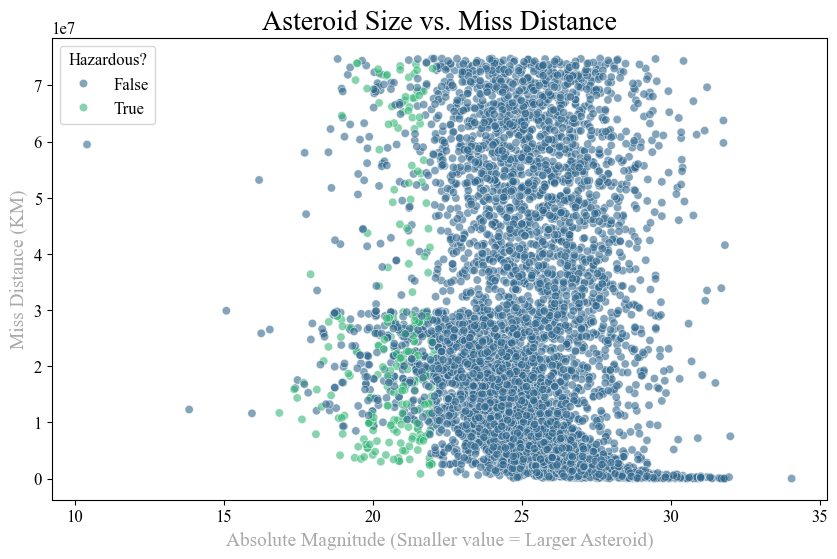

In [ ]:
# Scatter plot of Absolute Magnitude vs. Miss Distance, color-coded by hazard status to identify safety patterns.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, 
                x='absolute_magnitude_h', 
                y='miss_distance_kilometers', 
                hue='is_potentially_hazardous_asteroid', 
                palette='viridis',
                alpha=0.6)

plt.title('Asteroid Size vs. Miss Distance')
plt.xlabel('Absolute Magnitude (Smaller value = Larger Asteroid)')
plt.ylabel('Miss Distance (KM)')
plt.legend(title='Hazardous?')
plt.show()

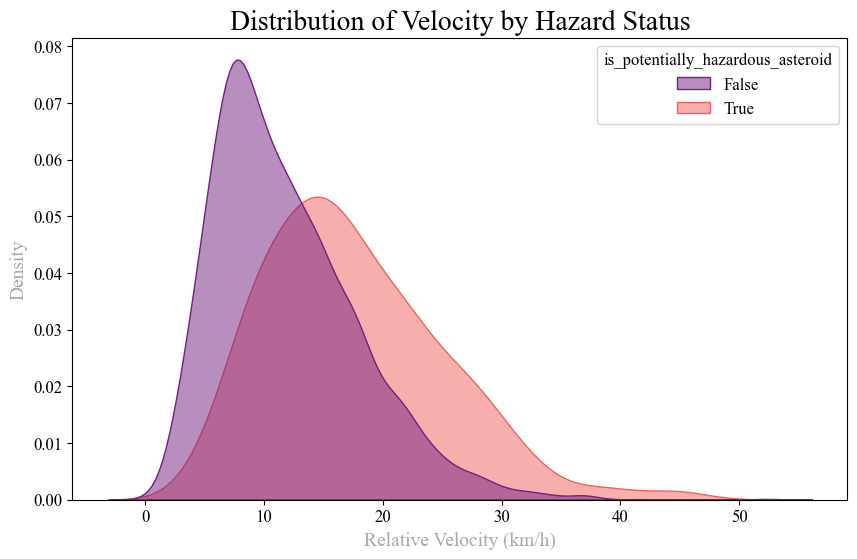

In [ ]:
# Kernel Density Estimate (KDE) plot showing the velocity distribution density for hazardous vs. non-hazardous asteroids.
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, 
            x='relative_velocity_km_per_sec', 
            hue='is_potentially_hazardous_asteroid', 
            fill=True, 
            common_norm=False, 
            palette='magma', 
            alpha=0.5)

plt.title('Distribution of Velocity by Hazard Status')
plt.xlabel('Relative Velocity (km/h)')
plt.ylabel('Density')
plt.show()


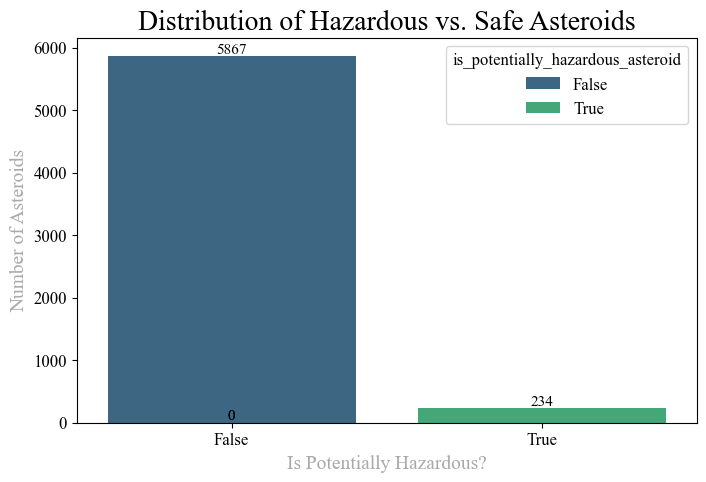

In [ ]:
# Count plot showing the frequency of safe vs. hazardous asteroids with data labels for exact totals
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='is_potentially_hazardous_asteroid', hue='is_potentially_hazardous_asteroid', palette='viridis')

plt.title('Distribution of Hazardous vs. Safe Asteroids')
plt.xlabel('Is Potentially Hazardous?')
plt.ylabel('Number of Asteroids')

# This adds the actual counts on top of the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')
plt.show()

getting data ready for training

predictor value = potentially_hazardous_asteroid

In [ ]:
# Define the features by dropping the target column and define the target variable
X = df.drop(columns=["is_potentially_hazardous_asteroid"])
y = df['is_potentially_hazardous_asteroid']

In [ ]:
# Change the data type from boolean/object to integer
X['is_sentry_object'] = X['is_sentry_object'].astype(int)

In [ ]:
# Create a 80/20 split of the data to ensure the model is tested on unseen data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize the scaler and adjust it based on the training data, then apply transformation to both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression

In [ ]:
# Create the Logistic Regression model using the liblinear solver
model = LogisticRegression(solver='liblinear')
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
# Compute the mean accuracy of the model relative to the unseen test features and labels
model.score(X_test_scaled, y_test)

0.9656019656019657

In [ ]:
# Initialize Models
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [ ]:
# Train and Predict
results = {}
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {'pred': y_pred, 'prob': y_prob, 'model': model}

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:50:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# Classification Reports
for name in results:
    print(f"\n{name} Score Report")
    print(classification_report(y_test, results[name]['pred']))


Logistic Regression Score Report
              precision    recall  f1-score   support

       False       0.97      0.99      0.98      1179
        True       0.50      0.14      0.22        42

    accuracy                           0.97      1221
   macro avg       0.74      0.57      0.60      1221
weighted avg       0.95      0.97      0.96      1221


Random Forest Score Report
              precision    recall  f1-score   support

       False       0.98      0.98      0.98      1179
        True       0.51      0.48      0.49        42

    accuracy                           0.97      1221
   macro avg       0.75      0.73      0.74      1221
weighted avg       0.97      0.97      0.97      1221


XGBoost Score Report
              precision    recall  f1-score   support

       False       0.98      0.99      0.98      1179
        True       0.57      0.48      0.52        42

    accuracy                           0.97      1221
   macro avg       0.78      0.73      0.75 

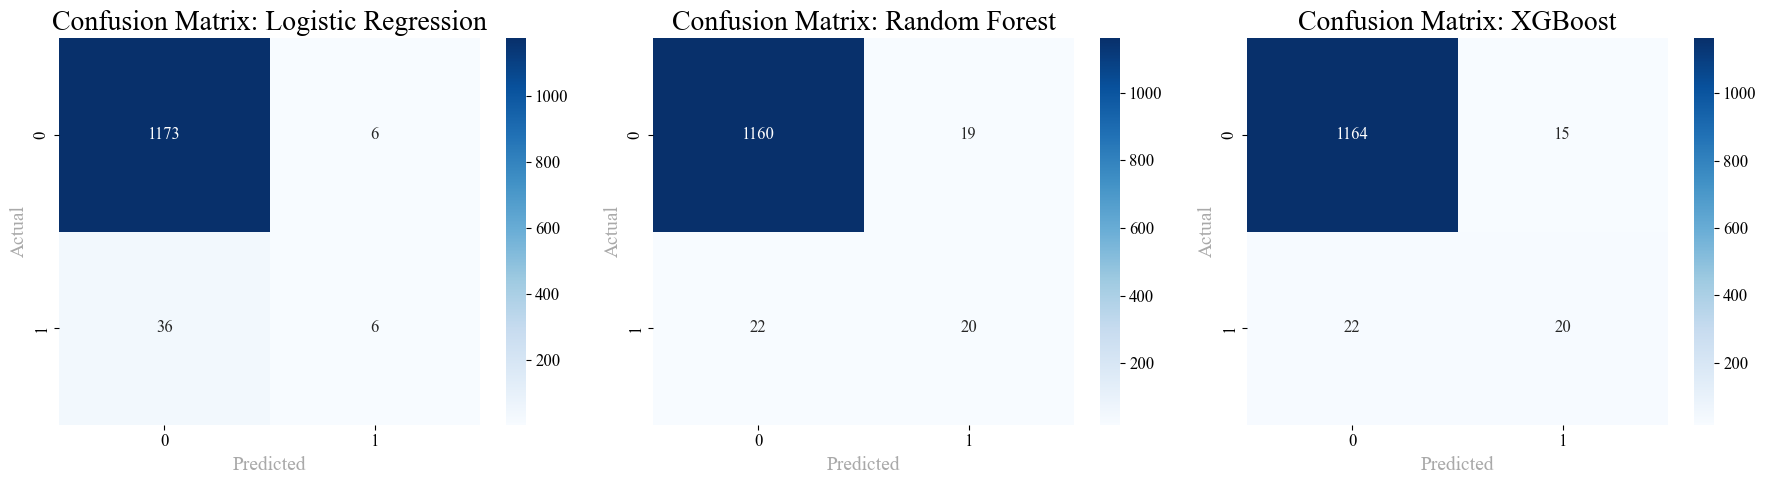

In [ ]:
# Visualizations: Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

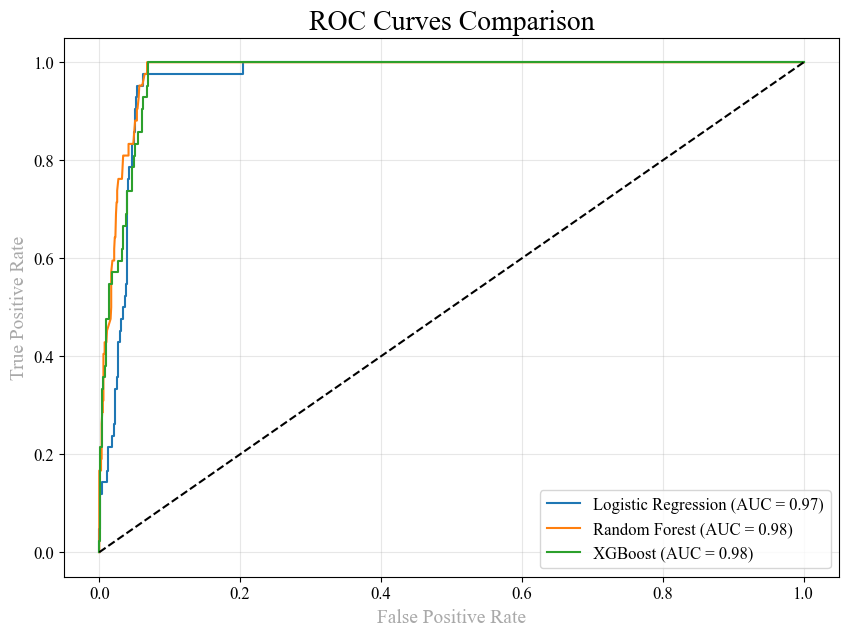

In [ ]:
# Visualizations: ROC-AUC Curves
plt.figure(figsize=(10, 7))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

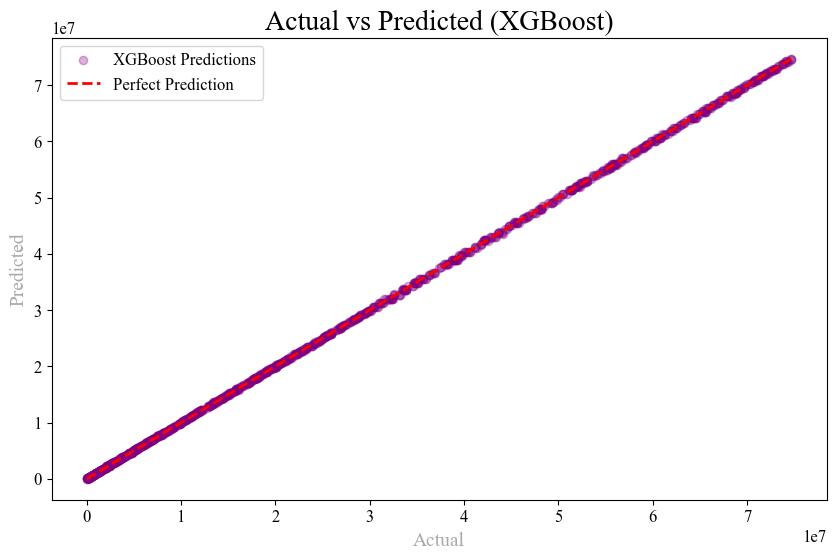

In [ ]:
# Visualization (Predicted vs Actual)
# Define Features (X) and Target (y)
y = df['miss_distance_kilometers']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='purple', label='XGBoost Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs Predicted (XGBoost)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()

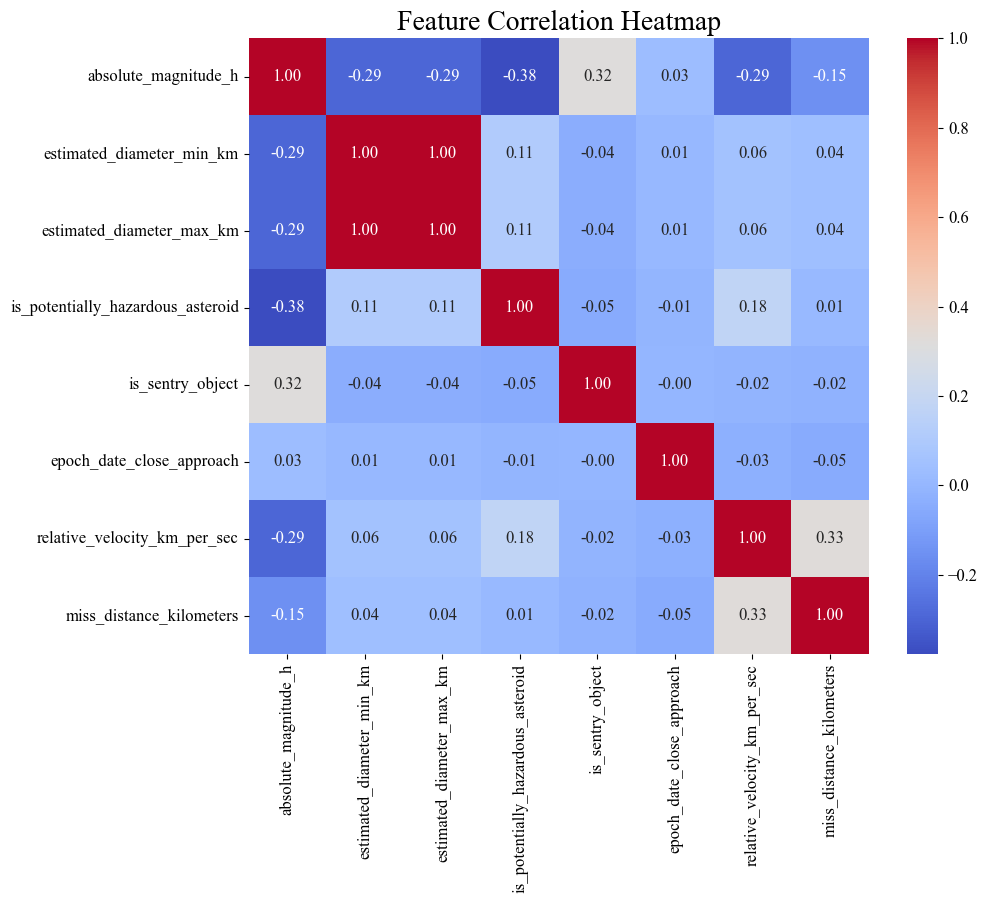

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
# Final Regression Evaluation
print("\nFinal Regression Evaluation")

def print_regression_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{model_name} Metrics:")
    print(f"  Mean Absolute Error (MAE): {mae:,.2f} km")
    print(f"  Root Mean Squared Error (RMSE): {rmse:,.2f} km")
    print(f"  R^2 Score: {r2:.4f}")
    print("-" * 30)

# Evaluate your XGBoost model
print_regression_metrics(y_test, y_pred_xgb, "XGBoost")


Final Regression Evaluation
XGBoost Metrics:
  Mean Absolute Error (MAE): 16,825,956.05 km
  Root Mean Squared Error (RMSE): 20,646,309.71 km
  R^2 Score: 0.1775
------------------------------


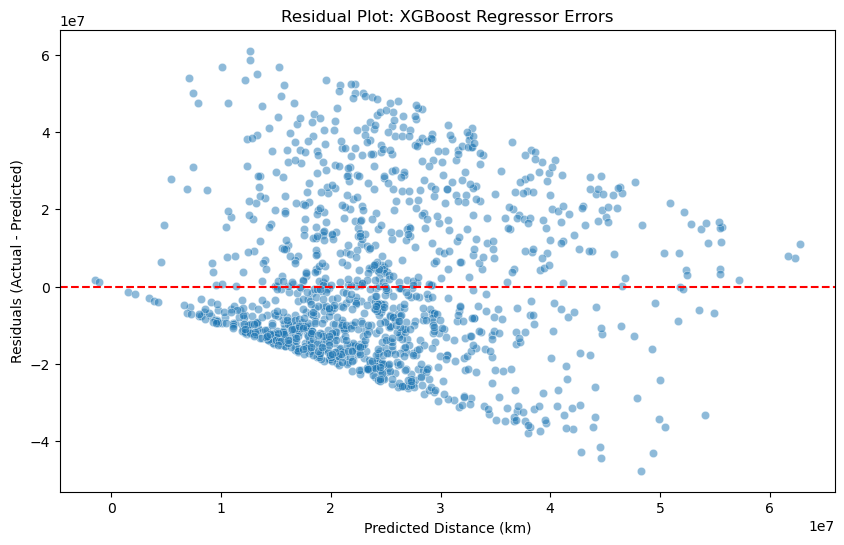

In [ ]:
# Residual Plot
residuals = y_test - y_pred_xgb

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_xgb, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Distance (km)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: XGBoost Regressor Errors')
plt.show()